In [1]:
import torch
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
from torch.optim import Adam
import matplotlib.pyplot as plt
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np

In [2]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_DIM = 100 
IMAGE_SIZE = 28 * 28 
BATCH_SIZE = 128
LEARNING_RATE = 0.0002
BETA1 = 0.5 
NUM_EPOCHS = 50

print(f"Device: {DEVICE}")

Device: cuda


In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim, image_size):
        super(Generator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(256),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(512),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.BatchNorm1d(1024),

            nn.Linear(1024, image_size),
            nn.Tanh()  # Sortie entre -1 et 1
        )

    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, image_size):
        super(Discriminator, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(image_size, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()  # Probabilité entre 0 et 1
        )

    def forward(self, img):
        """img: image aplatie de dimension image_size"""
        return self.model(img)

In [17]:
def load_data():
    """Charge le dataset MNIST"""
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5]) 
    ])

    dataset = datasets.FashionMNIST(
        root='./data',
        train=True,
        download=True,
        transform=transform
    )

    dataloader = DataLoader(
        dataset,
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=2
    )

    return dataloader

In [18]:
generator = Generator(LATENT_DIM, IMAGE_SIZE).to(DEVICE)
discriminator = Discriminator(IMAGE_SIZE).to(DEVICE)

criterion = nn.BCELoss()  # Binary Cross Entropy Loss
optimizer_G = Adam(generator.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))
optimizer_D = Adam(discriminator.parameters(), lr=LEARNING_RATE, betas=(BETA1, 0.999))

dataloader = load_data()

# Labels
real_label = 1.0
fake_label = 0.0

G_losses = []
D_losses = []

100%|██████████| 26.4M/26.4M [00:01<00:00, 14.4MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 216kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.98MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 7.53MB/s]


In [19]:
def generate_and_plot(generator, noise, num_images=16):
    
    generator.eval()
    with torch.no_grad():
        fake_imgs = generator(noise).cpu().view(-1, 1, 28, 28)

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i in range(num_images):
        ax = axes[i // 4, i % 4]
        ax.imshow(fake_imgs[i].squeeze(), cmap='gray')
        ax.axis('off')
    plt.show()

Training GAN...
Epoch [1/50] Batch 0/469                     Loss D: 0.5819, Loss G: 2.9101
Epoch [1/50] Batch 100/469                     Loss D: 0.7843, Loss G: 3.1260
Epoch [1/50] Batch 200/469                     Loss D: 0.7630, Loss G: 2.3821
Epoch [1/50] Batch 300/469                     Loss D: 1.0417, Loss G: 1.4335
Epoch [1/50] Batch 400/469                     Loss D: 0.7302, Loss G: 2.7546


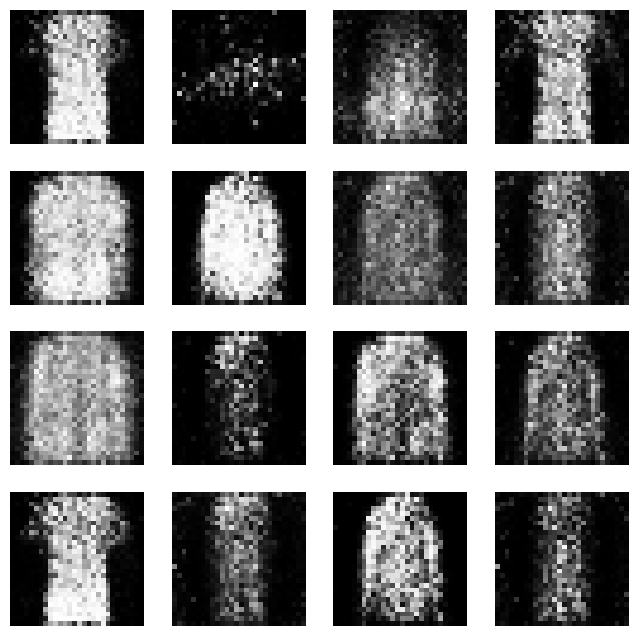

Epoch [2/50] Batch 0/469                     Loss D: 0.9038, Loss G: 2.4484
Epoch [2/50] Batch 100/469                     Loss D: 1.3095, Loss G: 1.1466
Epoch [2/50] Batch 200/469                     Loss D: 0.9931, Loss G: 1.2796
Epoch [2/50] Batch 300/469                     Loss D: 0.8204, Loss G: 1.7306
Epoch [2/50] Batch 400/469                     Loss D: 0.8226, Loss G: 1.7990


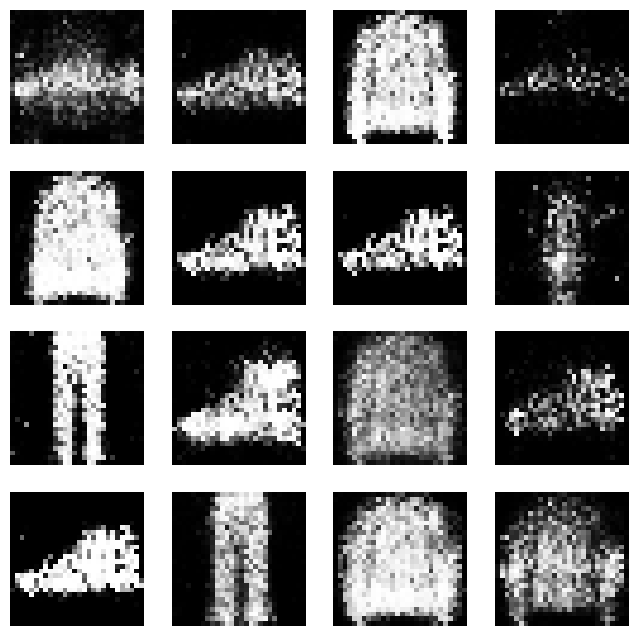

Epoch [3/50] Batch 0/469                     Loss D: 0.9464, Loss G: 2.7189
Epoch [3/50] Batch 100/469                     Loss D: 1.0026, Loss G: 1.9868
Epoch [3/50] Batch 200/469                     Loss D: 0.9174, Loss G: 1.4379
Epoch [3/50] Batch 300/469                     Loss D: 1.1344, Loss G: 2.1273
Epoch [3/50] Batch 400/469                     Loss D: 1.0422, Loss G: 1.5622


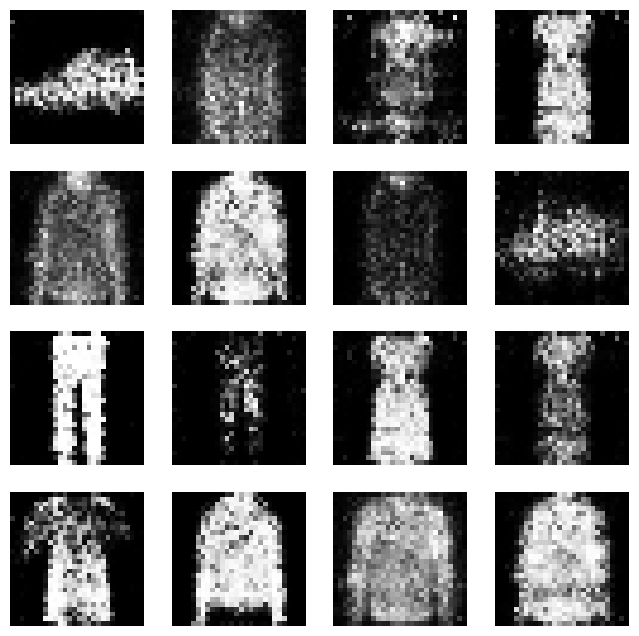

Epoch [4/50] Batch 0/469                     Loss D: 0.9003, Loss G: 1.5614
Epoch [4/50] Batch 100/469                     Loss D: 0.8611, Loss G: 1.2598
Epoch [4/50] Batch 200/469                     Loss D: 1.1256, Loss G: 0.9528
Epoch [4/50] Batch 300/469                     Loss D: 1.0476, Loss G: 1.1915
Epoch [4/50] Batch 400/469                     Loss D: 1.0173, Loss G: 1.4159


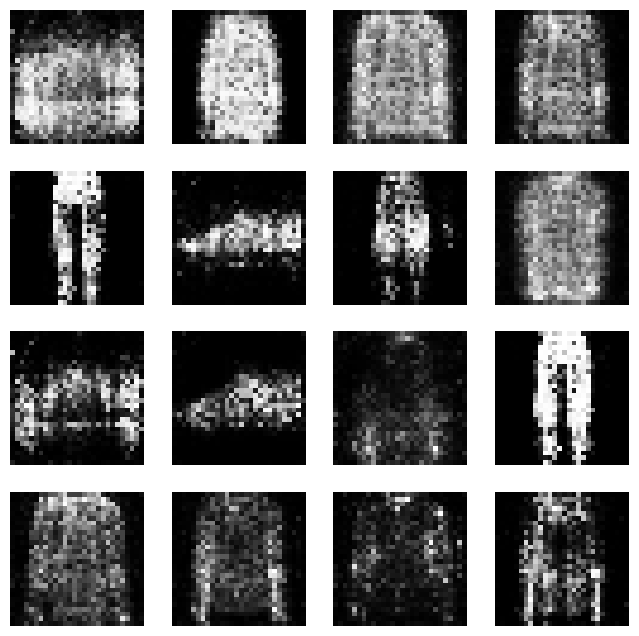

Epoch [5/50] Batch 0/469                     Loss D: 1.0974, Loss G: 1.6264
Epoch [5/50] Batch 100/469                     Loss D: 1.0678, Loss G: 1.4459
Epoch [5/50] Batch 200/469                     Loss D: 0.9968, Loss G: 1.2466
Epoch [5/50] Batch 300/469                     Loss D: 0.9799, Loss G: 1.4862
Epoch [5/50] Batch 400/469                     Loss D: 1.0492, Loss G: 1.2612


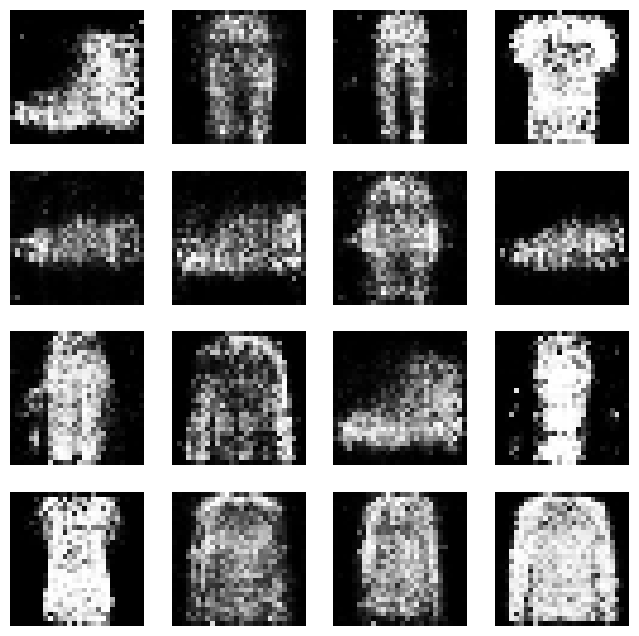

Epoch [6/50] Batch 0/469                     Loss D: 1.0201, Loss G: 1.5792
Epoch [6/50] Batch 100/469                     Loss D: 1.1407, Loss G: 1.1864
Epoch [6/50] Batch 200/469                     Loss D: 1.0641, Loss G: 1.4205
Epoch [6/50] Batch 300/469                     Loss D: 1.0615, Loss G: 1.5089
Epoch [6/50] Batch 400/469                     Loss D: 1.1333, Loss G: 1.9117


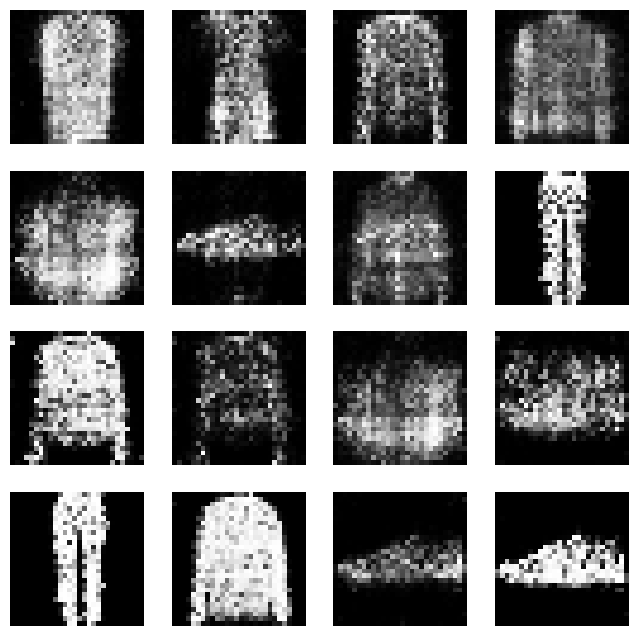

Epoch [7/50] Batch 0/469                     Loss D: 1.0703, Loss G: 1.6293
Epoch [7/50] Batch 100/469                     Loss D: 1.1664, Loss G: 1.0944
Epoch [7/50] Batch 200/469                     Loss D: 1.0948, Loss G: 1.1324
Epoch [7/50] Batch 300/469                     Loss D: 1.0790, Loss G: 1.3464
Epoch [7/50] Batch 400/469                     Loss D: 1.1758, Loss G: 1.6564


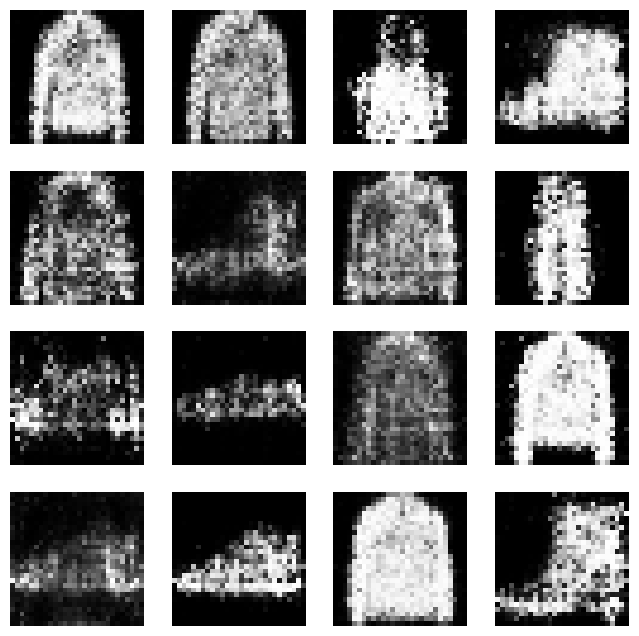

Epoch [8/50] Batch 0/469                     Loss D: 1.0835, Loss G: 1.3935
Epoch [8/50] Batch 100/469                     Loss D: 1.1277, Loss G: 1.3007
Epoch [8/50] Batch 200/469                     Loss D: 1.2440, Loss G: 1.0209
Epoch [8/50] Batch 300/469                     Loss D: 1.1608, Loss G: 1.2705
Epoch [8/50] Batch 400/469                     Loss D: 1.1945, Loss G: 1.2650


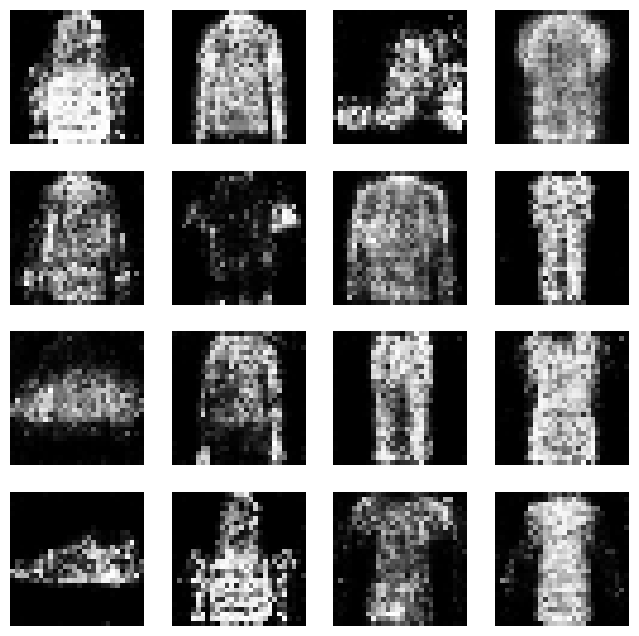

Epoch [9/50] Batch 0/469                     Loss D: 1.1630, Loss G: 1.2468
Epoch [9/50] Batch 100/469                     Loss D: 1.0968, Loss G: 1.2144
Epoch [9/50] Batch 200/469                     Loss D: 1.1869, Loss G: 1.0845
Epoch [9/50] Batch 300/469                     Loss D: 1.0990, Loss G: 1.0325
Epoch [9/50] Batch 400/469                     Loss D: 1.1878, Loss G: 1.0202


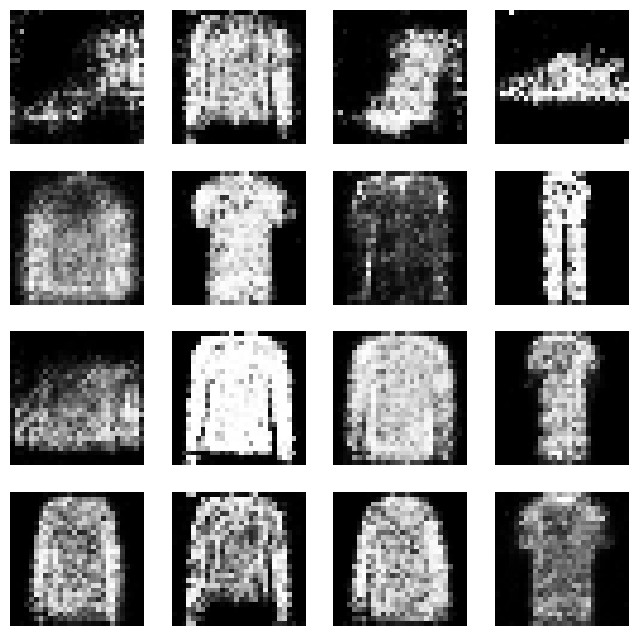

Epoch [10/50] Batch 0/469                     Loss D: 1.0803, Loss G: 1.0277
Epoch [10/50] Batch 100/469                     Loss D: 1.2248, Loss G: 1.1034
Epoch [10/50] Batch 200/469                     Loss D: 1.1064, Loss G: 1.2907
Epoch [10/50] Batch 300/469                     Loss D: 1.1724, Loss G: 1.1741
Epoch [10/50] Batch 400/469                     Loss D: 1.0369, Loss G: 1.0819


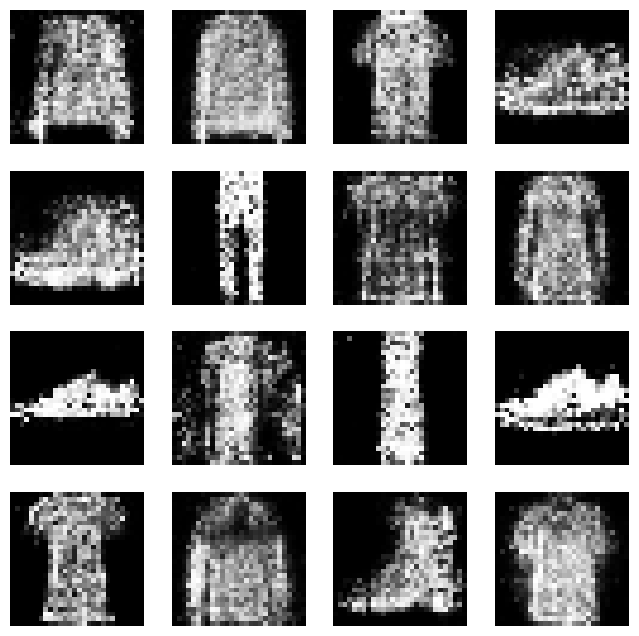

Epoch [11/50] Batch 0/469                     Loss D: 1.1339, Loss G: 1.0641
Epoch [11/50] Batch 100/469                     Loss D: 1.2341, Loss G: 1.0982
Epoch [11/50] Batch 200/469                     Loss D: 1.1251, Loss G: 1.1466
Epoch [11/50] Batch 300/469                     Loss D: 1.2799, Loss G: 1.0990
Epoch [11/50] Batch 400/469                     Loss D: 1.2168, Loss G: 1.0273


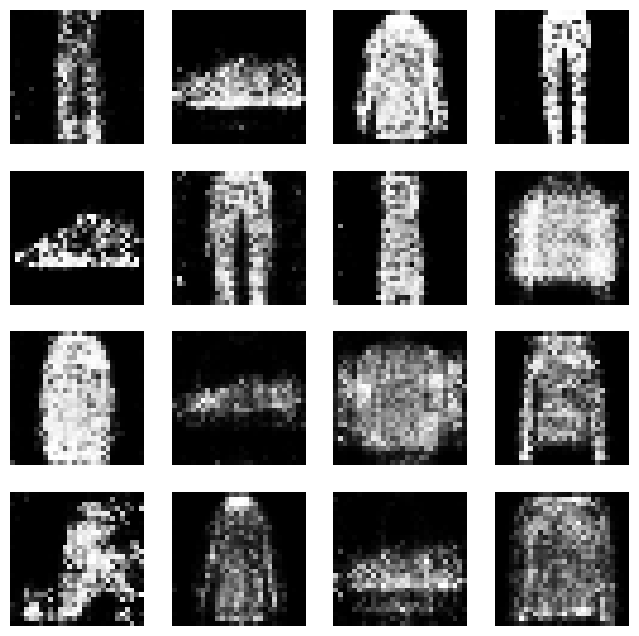

Epoch [12/50] Batch 0/469                     Loss D: 1.2585, Loss G: 1.1406
Epoch [12/50] Batch 100/469                     Loss D: 1.2602, Loss G: 0.9735
Epoch [12/50] Batch 200/469                     Loss D: 1.2758, Loss G: 1.0286
Epoch [12/50] Batch 300/469                     Loss D: 1.1523, Loss G: 1.0432
Epoch [12/50] Batch 400/469                     Loss D: 1.2305, Loss G: 0.9873


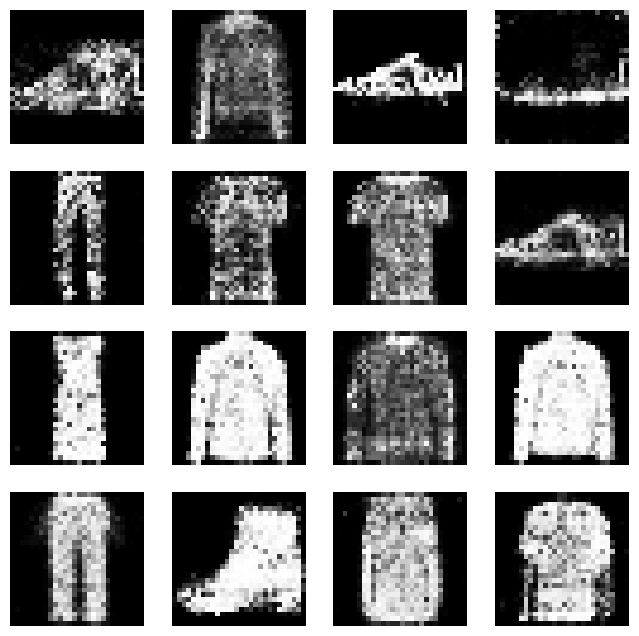

Epoch [13/50] Batch 0/469                     Loss D: 1.1544, Loss G: 0.9831
Epoch [13/50] Batch 100/469                     Loss D: 1.1520, Loss G: 1.1319
Epoch [13/50] Batch 200/469                     Loss D: 1.2092, Loss G: 1.0747
Epoch [13/50] Batch 300/469                     Loss D: 1.2678, Loss G: 1.0844
Epoch [13/50] Batch 400/469                     Loss D: 1.2489, Loss G: 0.9639


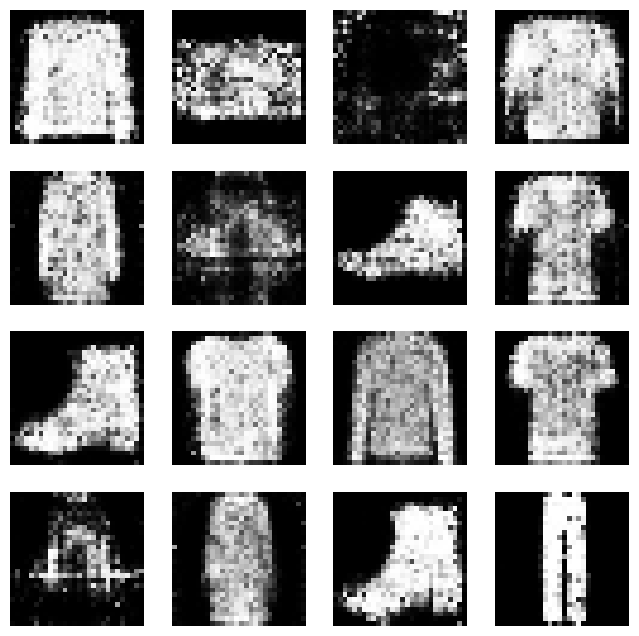

Epoch [14/50] Batch 0/469                     Loss D: 1.2824, Loss G: 1.0359
Epoch [14/50] Batch 100/469                     Loss D: 1.2339, Loss G: 1.0617
Epoch [14/50] Batch 200/469                     Loss D: 1.1334, Loss G: 0.9666
Epoch [14/50] Batch 300/469                     Loss D: 1.3208, Loss G: 0.9455
Epoch [14/50] Batch 400/469                     Loss D: 1.2843, Loss G: 1.0577


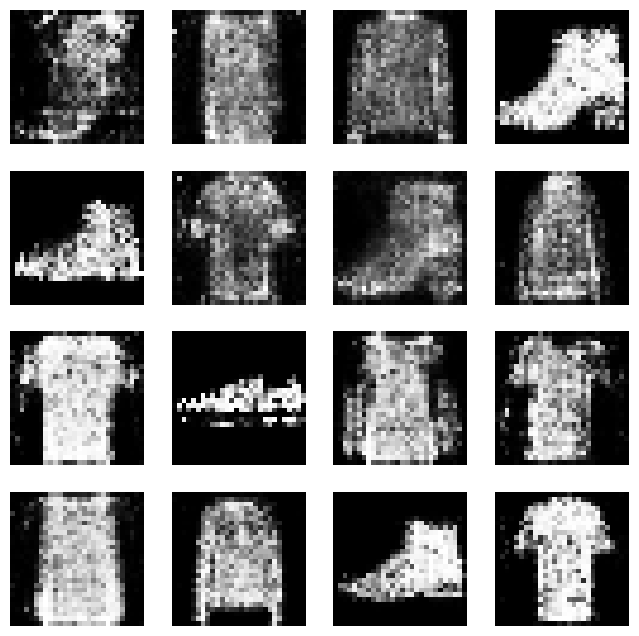

Epoch [15/50] Batch 0/469                     Loss D: 1.1060, Loss G: 1.1346
Epoch [15/50] Batch 100/469                     Loss D: 1.3405, Loss G: 1.1359
Epoch [15/50] Batch 200/469                     Loss D: 1.2675, Loss G: 1.0636
Epoch [15/50] Batch 300/469                     Loss D: 1.2769, Loss G: 0.9994
Epoch [15/50] Batch 400/469                     Loss D: 1.3491, Loss G: 1.0835


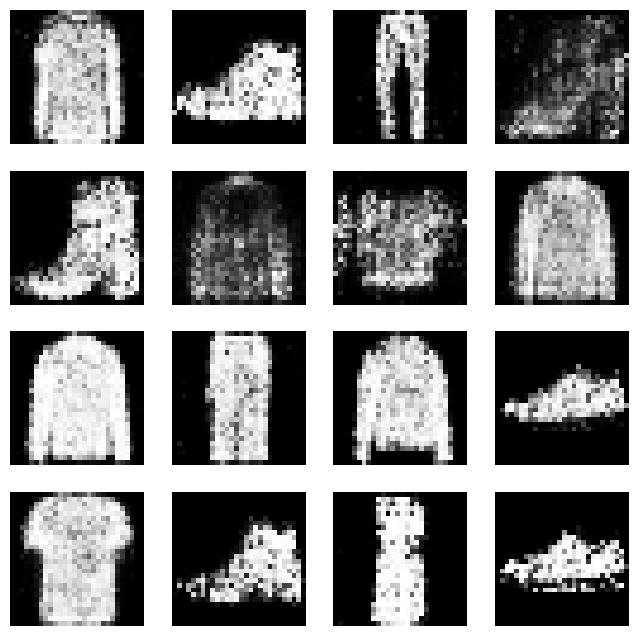

Epoch [16/50] Batch 0/469                     Loss D: 1.2230, Loss G: 1.0837
Epoch [16/50] Batch 100/469                     Loss D: 1.2513, Loss G: 1.0450
Epoch [16/50] Batch 200/469                     Loss D: 1.2142, Loss G: 0.9665
Epoch [16/50] Batch 300/469                     Loss D: 1.2034, Loss G: 1.0174
Epoch [16/50] Batch 400/469                     Loss D: 1.3150, Loss G: 0.9706


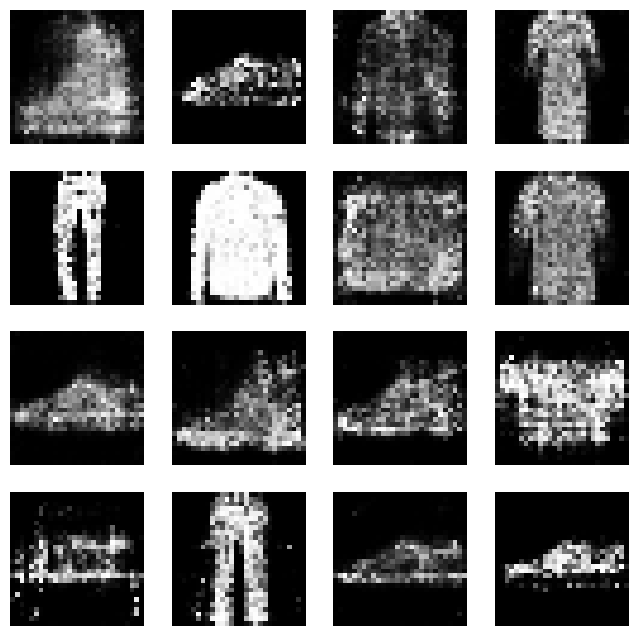

Epoch [17/50] Batch 0/469                     Loss D: 1.2625, Loss G: 0.9783
Epoch [17/50] Batch 100/469                     Loss D: 1.3131, Loss G: 1.0874
Epoch [17/50] Batch 200/469                     Loss D: 1.1792, Loss G: 1.0163
Epoch [17/50] Batch 300/469                     Loss D: 1.3481, Loss G: 0.9675
Epoch [17/50] Batch 400/469                     Loss D: 1.3914, Loss G: 0.9251


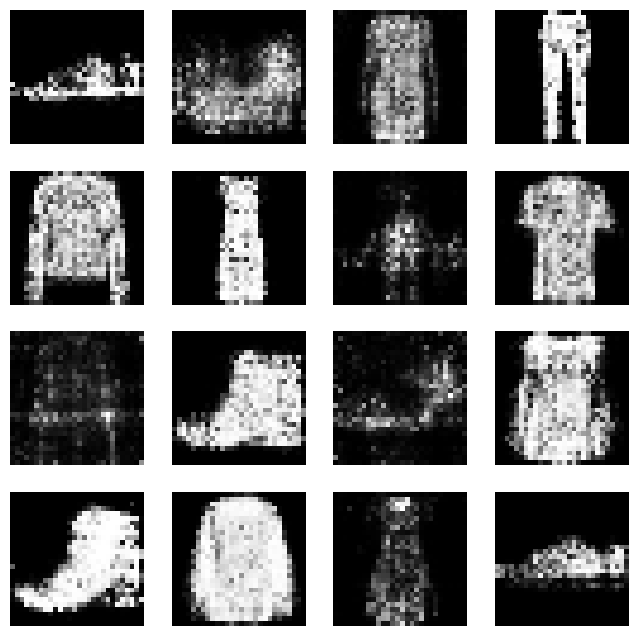

Epoch [18/50] Batch 0/469                     Loss D: 1.3144, Loss G: 1.0663
Epoch [18/50] Batch 100/469                     Loss D: 1.1927, Loss G: 0.9550
Epoch [18/50] Batch 200/469                     Loss D: 1.3133, Loss G: 0.9736
Epoch [18/50] Batch 300/469                     Loss D: 1.1882, Loss G: 0.9357
Epoch [18/50] Batch 400/469                     Loss D: 1.2406, Loss G: 1.0027


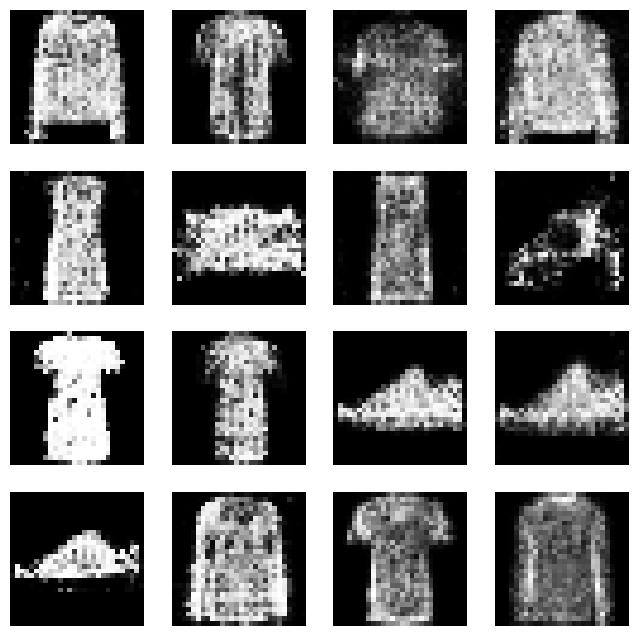

Epoch [19/50] Batch 0/469                     Loss D: 1.2433, Loss G: 0.9470
Epoch [19/50] Batch 100/469                     Loss D: 1.2514, Loss G: 0.8355
Epoch [19/50] Batch 200/469                     Loss D: 1.2034, Loss G: 0.9971
Epoch [19/50] Batch 300/469                     Loss D: 1.2719, Loss G: 1.0263
Epoch [19/50] Batch 400/469                     Loss D: 1.2998, Loss G: 0.8972


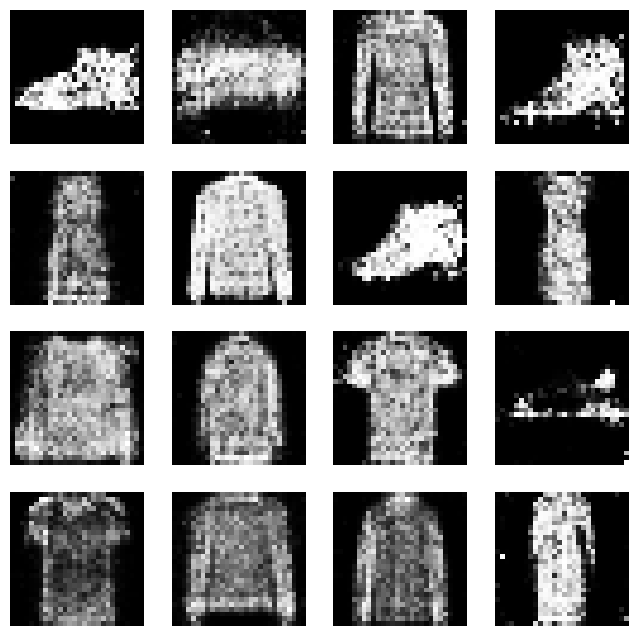

Epoch [20/50] Batch 0/469                     Loss D: 1.2746, Loss G: 1.0240
Epoch [20/50] Batch 100/469                     Loss D: 1.2960, Loss G: 0.9519
Epoch [20/50] Batch 200/469                     Loss D: 1.2247, Loss G: 0.9311
Epoch [20/50] Batch 300/469                     Loss D: 1.2854, Loss G: 0.9833
Epoch [20/50] Batch 400/469                     Loss D: 1.2632, Loss G: 0.8434


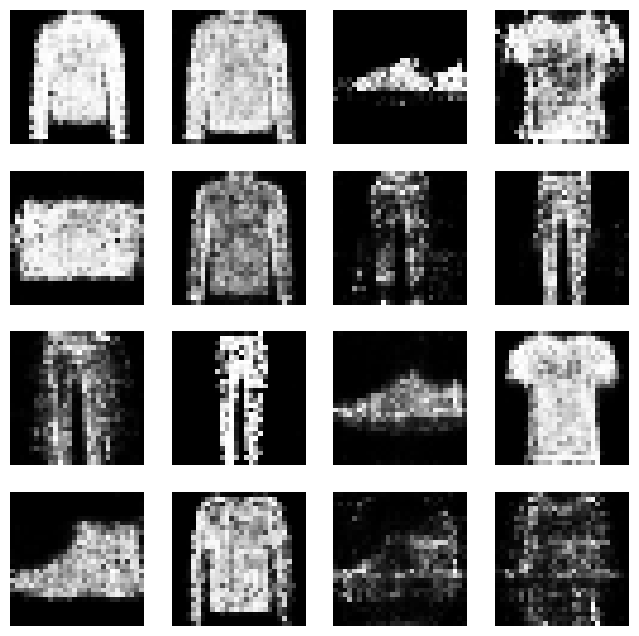

Epoch [21/50] Batch 0/469                     Loss D: 1.3030, Loss G: 0.9912
Epoch [21/50] Batch 100/469                     Loss D: 1.2963, Loss G: 0.9465
Epoch [21/50] Batch 200/469                     Loss D: 1.2982, Loss G: 0.8862
Epoch [21/50] Batch 300/469                     Loss D: 1.2992, Loss G: 1.0060
Epoch [21/50] Batch 400/469                     Loss D: 1.2156, Loss G: 0.9644


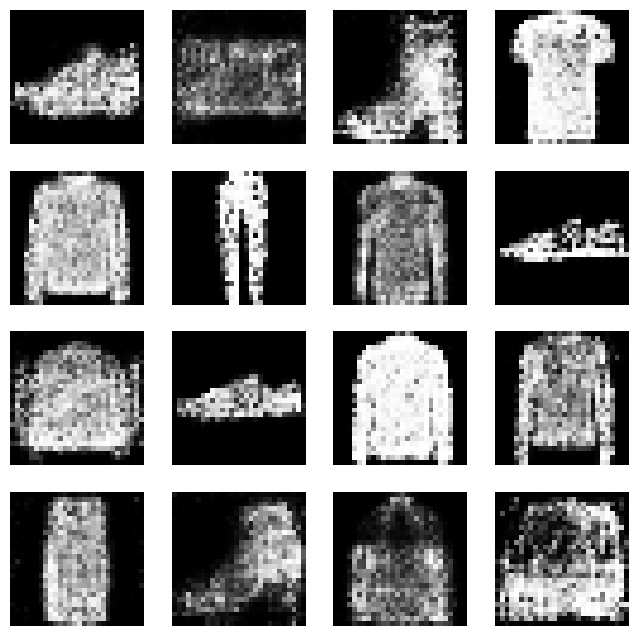

Epoch [22/50] Batch 0/469                     Loss D: 1.2541, Loss G: 0.9701
Epoch [22/50] Batch 100/469                     Loss D: 1.3512, Loss G: 0.9057
Epoch [22/50] Batch 200/469                     Loss D: 1.2825, Loss G: 0.9533
Epoch [22/50] Batch 300/469                     Loss D: 1.2783, Loss G: 1.0626
Epoch [22/50] Batch 400/469                     Loss D: 1.2349, Loss G: 0.9780


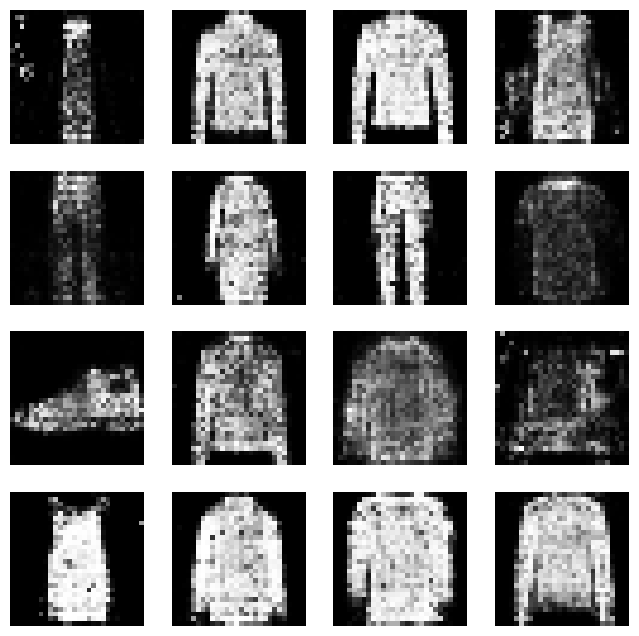

Epoch [23/50] Batch 0/469                     Loss D: 1.2250, Loss G: 0.8810
Epoch [23/50] Batch 100/469                     Loss D: 1.3457, Loss G: 1.0496
Epoch [23/50] Batch 200/469                     Loss D: 1.2350, Loss G: 0.8219
Epoch [23/50] Batch 300/469                     Loss D: 1.3446, Loss G: 0.9549
Epoch [23/50] Batch 400/469                     Loss D: 1.2238, Loss G: 0.9018


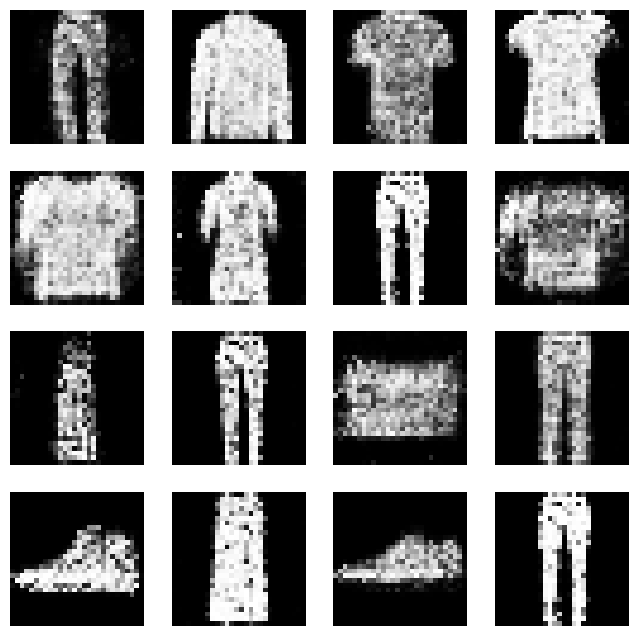

Epoch [24/50] Batch 0/469                     Loss D: 1.2452, Loss G: 0.9515
Epoch [24/50] Batch 100/469                     Loss D: 1.2727, Loss G: 0.9435
Epoch [24/50] Batch 200/469                     Loss D: 1.2854, Loss G: 1.0576
Epoch [24/50] Batch 300/469                     Loss D: 1.2330, Loss G: 0.8476
Epoch [24/50] Batch 400/469                     Loss D: 1.1860, Loss G: 1.0064


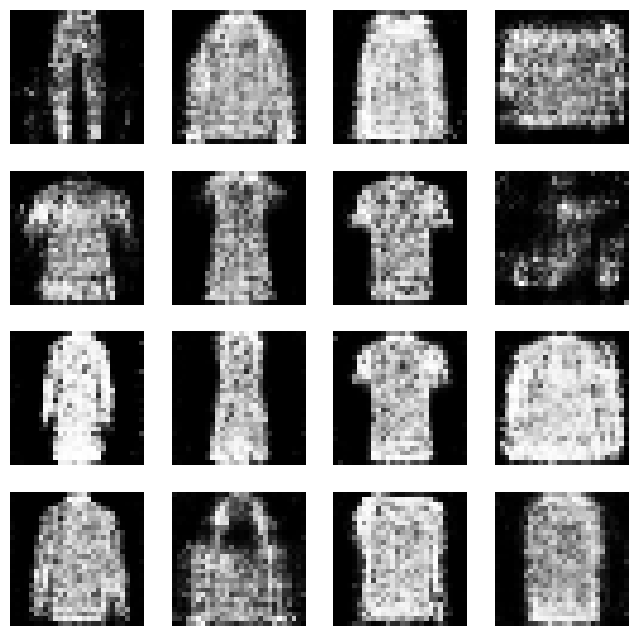

Epoch [25/50] Batch 0/469                     Loss D: 1.2655, Loss G: 0.9550
Epoch [25/50] Batch 100/469                     Loss D: 1.2939, Loss G: 1.0450
Epoch [25/50] Batch 200/469                     Loss D: 1.3254, Loss G: 0.8581
Epoch [25/50] Batch 300/469                     Loss D: 1.2349, Loss G: 0.9457
Epoch [25/50] Batch 400/469                     Loss D: 1.3073, Loss G: 0.8740


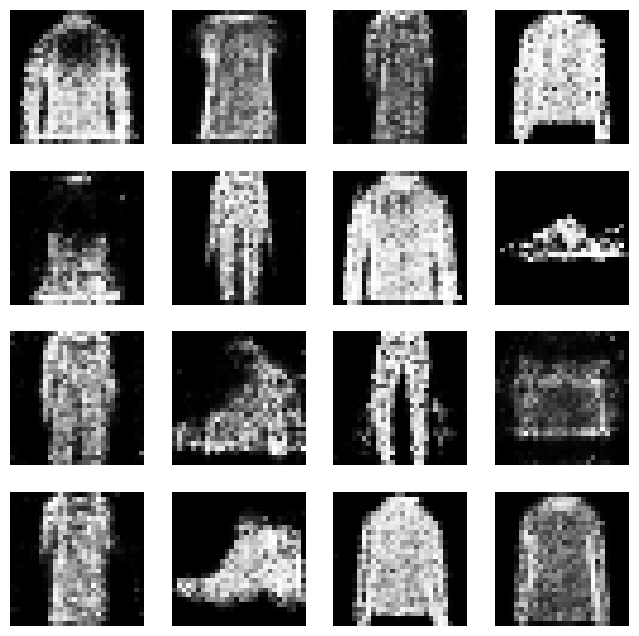

Epoch [26/50] Batch 0/469                     Loss D: 1.2069, Loss G: 0.8919
Epoch [26/50] Batch 100/469                     Loss D: 1.2905, Loss G: 0.8780
Epoch [26/50] Batch 200/469                     Loss D: 1.2424, Loss G: 0.9600
Epoch [26/50] Batch 300/469                     Loss D: 1.2370, Loss G: 0.9649
Epoch [26/50] Batch 400/469                     Loss D: 1.2308, Loss G: 0.8167


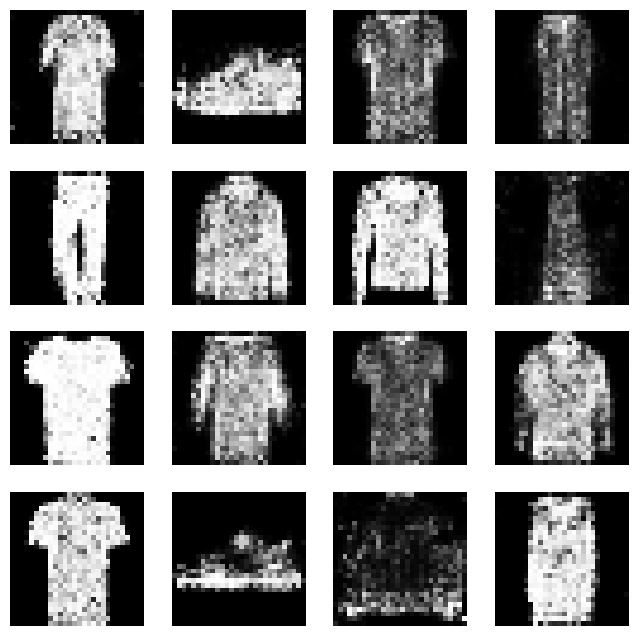

Epoch [27/50] Batch 0/469                     Loss D: 1.2844, Loss G: 1.0438
Epoch [27/50] Batch 100/469                     Loss D: 1.3344, Loss G: 0.8586
Epoch [27/50] Batch 200/469                     Loss D: 1.3123, Loss G: 0.8989
Epoch [27/50] Batch 300/469                     Loss D: 1.3333, Loss G: 0.9999
Epoch [27/50] Batch 400/469                     Loss D: 1.2745, Loss G: 0.9248


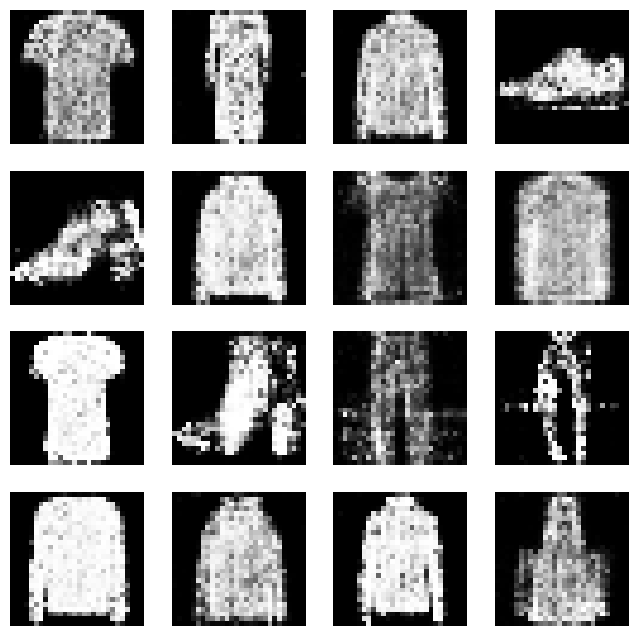

Epoch [28/50] Batch 0/469                     Loss D: 1.2310, Loss G: 0.8691
Epoch [28/50] Batch 100/469                     Loss D: 1.2487, Loss G: 0.9496
Epoch [28/50] Batch 200/469                     Loss D: 1.2305, Loss G: 0.9520
Epoch [28/50] Batch 300/469                     Loss D: 1.2813, Loss G: 0.8441
Epoch [28/50] Batch 400/469                     Loss D: 1.2949, Loss G: 1.0120


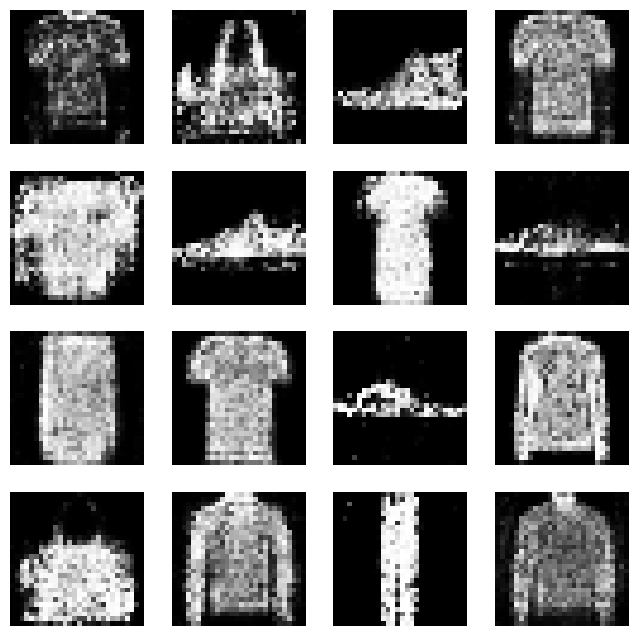

Epoch [29/50] Batch 0/469                     Loss D: 1.2691, Loss G: 0.8544
Epoch [29/50] Batch 100/469                     Loss D: 1.2082, Loss G: 0.8991
Epoch [29/50] Batch 200/469                     Loss D: 1.2960, Loss G: 0.9077
Epoch [29/50] Batch 300/469                     Loss D: 1.2752, Loss G: 0.8669
Epoch [29/50] Batch 400/469                     Loss D: 1.2214, Loss G: 0.9462


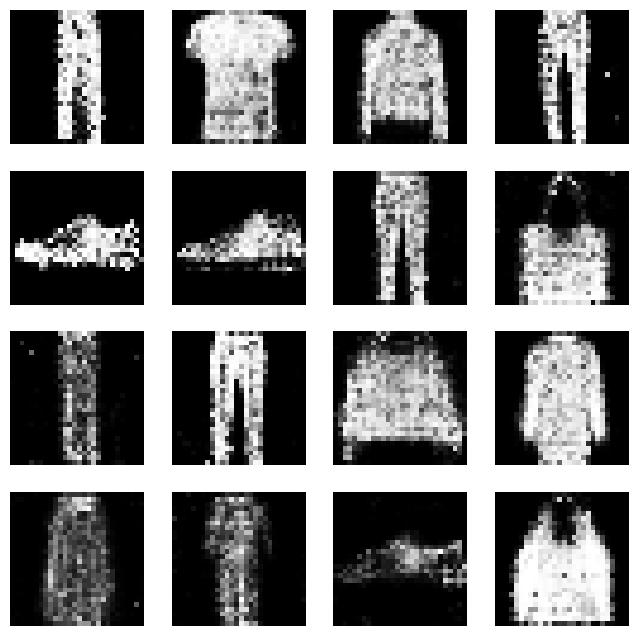

Epoch [30/50] Batch 0/469                     Loss D: 1.2858, Loss G: 1.0245
Epoch [30/50] Batch 100/469                     Loss D: 1.2844, Loss G: 0.8817
Epoch [30/50] Batch 200/469                     Loss D: 1.2789, Loss G: 0.9127
Epoch [30/50] Batch 300/469                     Loss D: 1.2858, Loss G: 0.9290
Epoch [30/50] Batch 400/469                     Loss D: 1.2910, Loss G: 0.8719


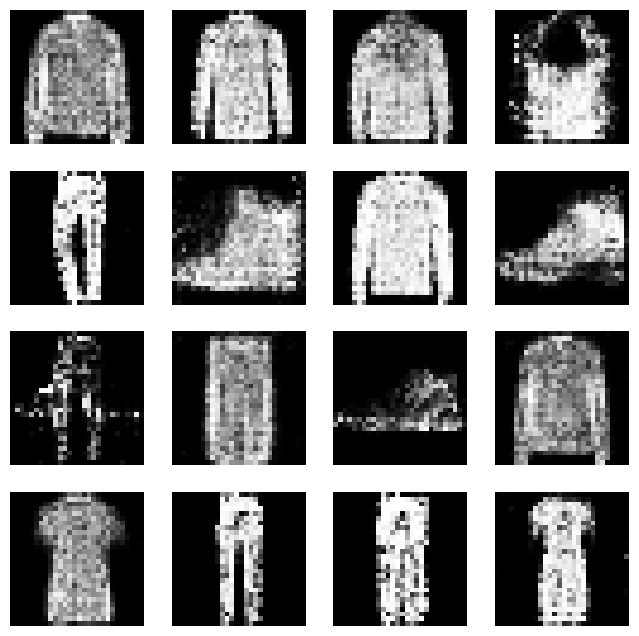

Epoch [31/50] Batch 0/469                     Loss D: 1.2845, Loss G: 0.8857
Epoch [31/50] Batch 100/469                     Loss D: 1.3200, Loss G: 0.8874
Epoch [31/50] Batch 200/469                     Loss D: 1.3376, Loss G: 0.9434
Epoch [31/50] Batch 300/469                     Loss D: 1.2887, Loss G: 0.8419
Epoch [31/50] Batch 400/469                     Loss D: 1.2996, Loss G: 0.8302


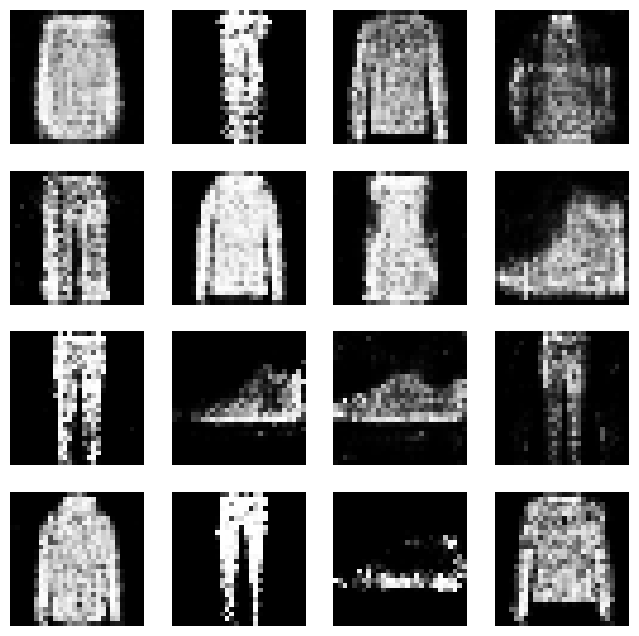

Epoch [32/50] Batch 0/469                     Loss D: 1.2894, Loss G: 0.8830
Epoch [32/50] Batch 100/469                     Loss D: 1.2757, Loss G: 0.9263
Epoch [32/50] Batch 200/469                     Loss D: 1.2281, Loss G: 0.9361
Epoch [32/50] Batch 300/469                     Loss D: 1.2460, Loss G: 0.9604
Epoch [32/50] Batch 400/469                     Loss D: 1.2734, Loss G: 0.9286


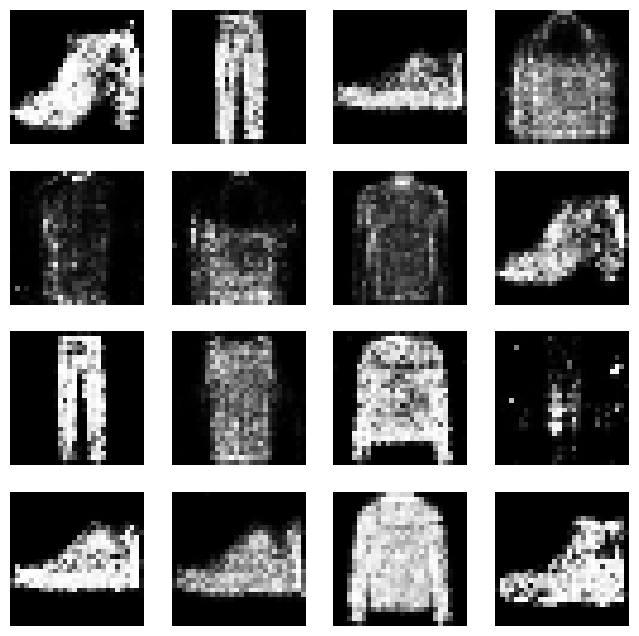

Epoch [33/50] Batch 0/469                     Loss D: 1.2462, Loss G: 0.9338
Epoch [33/50] Batch 100/469                     Loss D: 1.3028, Loss G: 0.9210
Epoch [33/50] Batch 200/469                     Loss D: 1.3027, Loss G: 0.8644
Epoch [33/50] Batch 300/469                     Loss D: 1.2251, Loss G: 0.9056
Epoch [33/50] Batch 400/469                     Loss D: 1.3038, Loss G: 0.9324


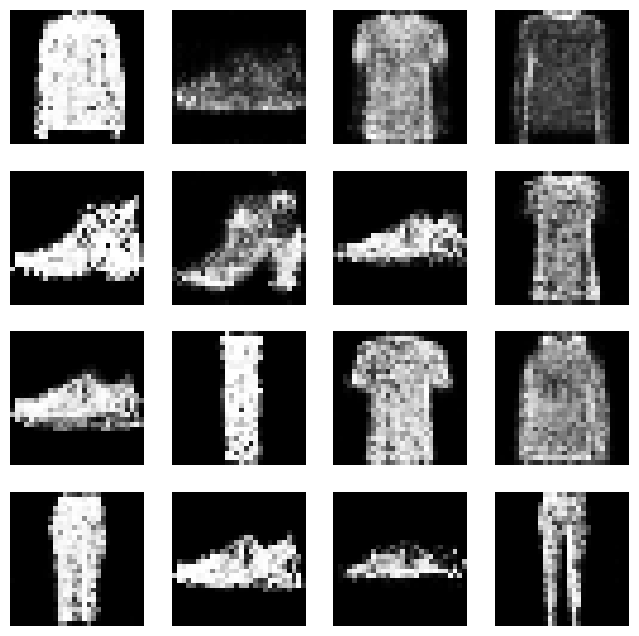

Epoch [34/50] Batch 0/469                     Loss D: 1.3586, Loss G: 0.9242
Epoch [34/50] Batch 100/469                     Loss D: 1.3272, Loss G: 0.8680
Epoch [34/50] Batch 200/469                     Loss D: 1.2518, Loss G: 0.9047
Epoch [34/50] Batch 300/469                     Loss D: 1.3359, Loss G: 0.9397
Epoch [34/50] Batch 400/469                     Loss D: 1.2984, Loss G: 0.9544


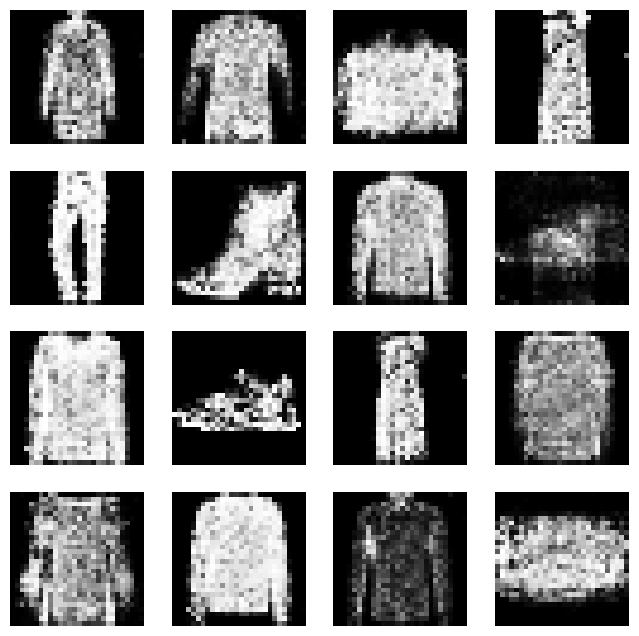

Epoch [35/50] Batch 0/469                     Loss D: 1.3045, Loss G: 0.9497
Epoch [35/50] Batch 100/469                     Loss D: 1.4008, Loss G: 0.8810
Epoch [35/50] Batch 200/469                     Loss D: 1.2458, Loss G: 0.8901
Epoch [35/50] Batch 300/469                     Loss D: 1.3021, Loss G: 0.8513
Epoch [35/50] Batch 400/469                     Loss D: 1.2297, Loss G: 0.8301


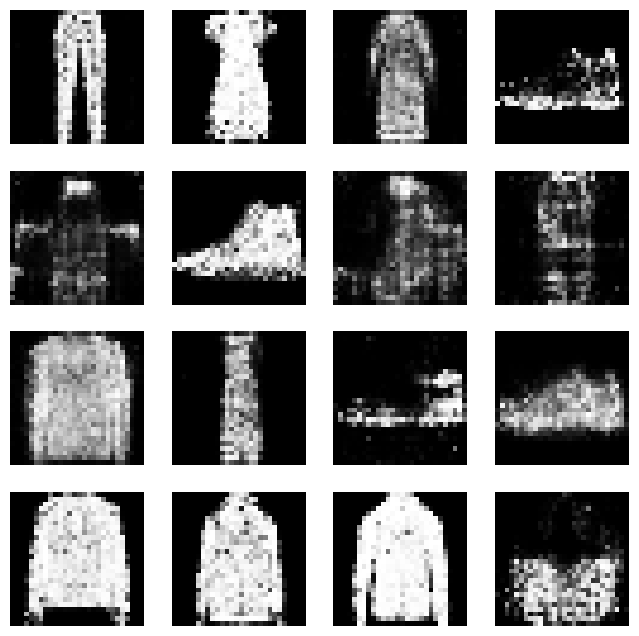

Epoch [36/50] Batch 0/469                     Loss D: 1.2299, Loss G: 0.8942
Epoch [36/50] Batch 100/469                     Loss D: 1.3252, Loss G: 0.9681
Epoch [36/50] Batch 200/469                     Loss D: 1.2664, Loss G: 0.8809
Epoch [36/50] Batch 300/469                     Loss D: 1.2853, Loss G: 0.8177
Epoch [36/50] Batch 400/469                     Loss D: 1.3354, Loss G: 0.8612


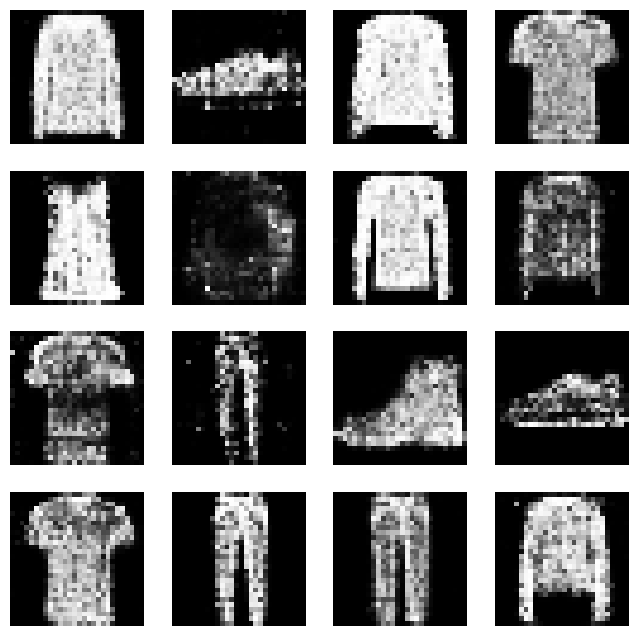

Epoch [37/50] Batch 0/469                     Loss D: 1.2401, Loss G: 0.9688
Epoch [37/50] Batch 100/469                     Loss D: 1.3427, Loss G: 0.9414
Epoch [37/50] Batch 200/469                     Loss D: 1.3004, Loss G: 0.8573
Epoch [37/50] Batch 300/469                     Loss D: 1.3052, Loss G: 0.8971
Epoch [37/50] Batch 400/469                     Loss D: 1.2338, Loss G: 0.9296


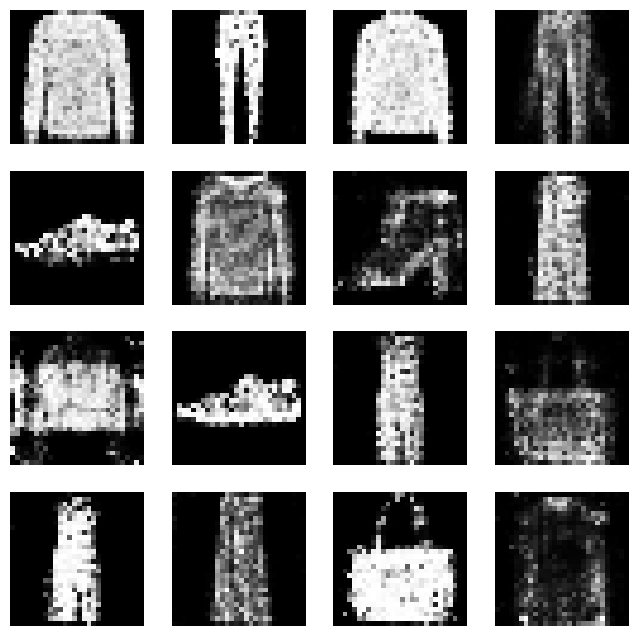

Epoch [38/50] Batch 0/469                     Loss D: 1.2978, Loss G: 0.8865
Epoch [38/50] Batch 100/469                     Loss D: 1.3576, Loss G: 0.9441
Epoch [38/50] Batch 200/469                     Loss D: 1.2644, Loss G: 0.9627
Epoch [38/50] Batch 300/469                     Loss D: 1.3109, Loss G: 0.9286
Epoch [38/50] Batch 400/469                     Loss D: 1.2853, Loss G: 0.8753


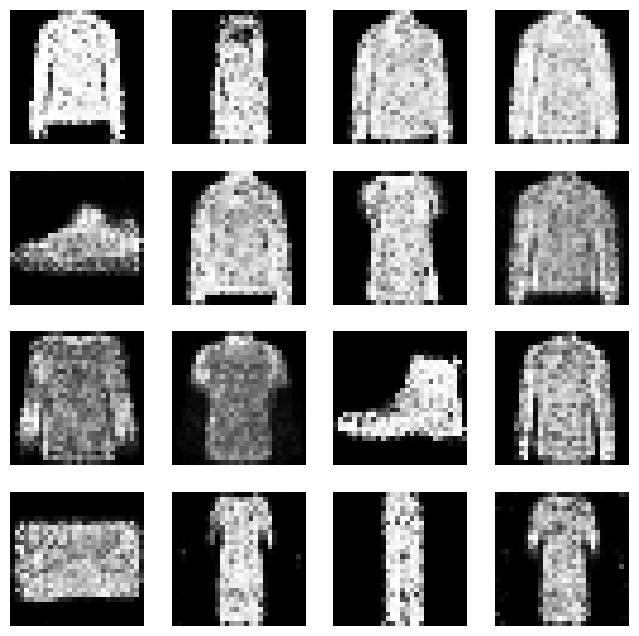

Epoch [39/50] Batch 0/469                     Loss D: 1.3392, Loss G: 0.9164
Epoch [39/50] Batch 100/469                     Loss D: 1.2370, Loss G: 0.8660
Epoch [39/50] Batch 200/469                     Loss D: 1.2759, Loss G: 0.9076
Epoch [39/50] Batch 300/469                     Loss D: 1.4119, Loss G: 0.9672
Epoch [39/50] Batch 400/469                     Loss D: 1.2858, Loss G: 0.9598


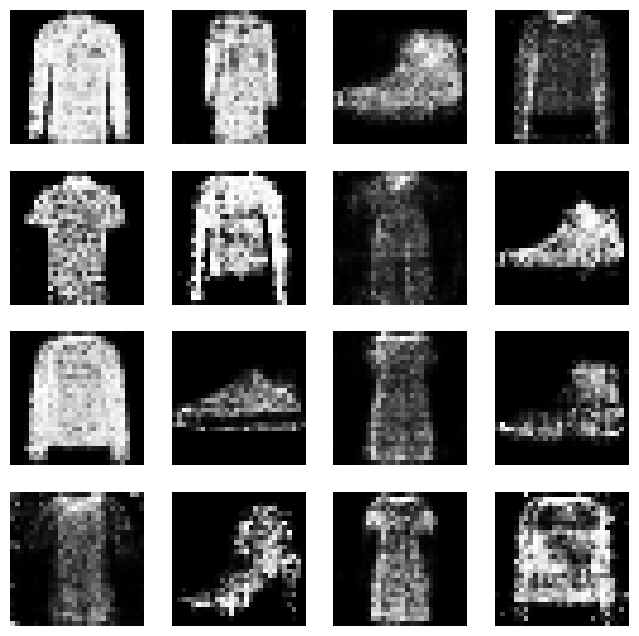

Epoch [40/50] Batch 0/469                     Loss D: 1.1687, Loss G: 0.9825
Epoch [40/50] Batch 100/469                     Loss D: 1.2962, Loss G: 0.9377
Epoch [40/50] Batch 200/469                     Loss D: 1.3873, Loss G: 0.9171
Epoch [40/50] Batch 300/469                     Loss D: 1.3088, Loss G: 0.8468
Epoch [40/50] Batch 400/469                     Loss D: 1.2117, Loss G: 0.8354


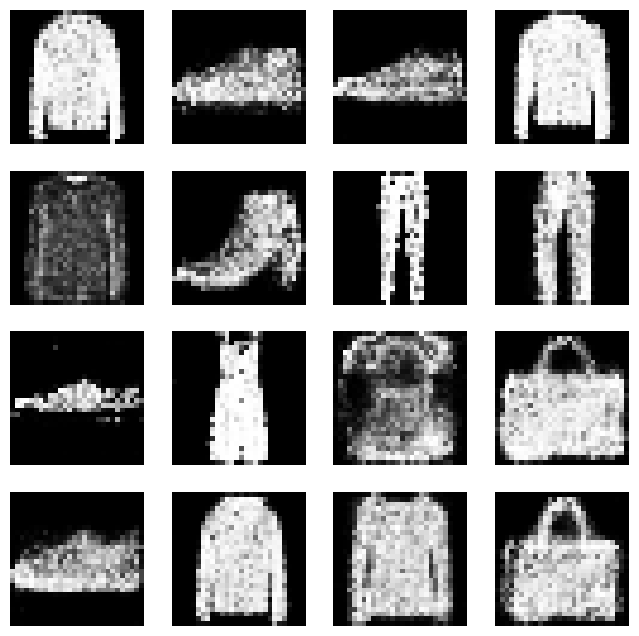

Epoch [41/50] Batch 0/469                     Loss D: 1.3217, Loss G: 0.8263
Epoch [41/50] Batch 100/469                     Loss D: 1.3520, Loss G: 0.9498
Epoch [41/50] Batch 200/469                     Loss D: 1.3151, Loss G: 0.8065
Epoch [41/50] Batch 300/469                     Loss D: 1.3167, Loss G: 0.9430
Epoch [41/50] Batch 400/469                     Loss D: 1.2734, Loss G: 0.8919


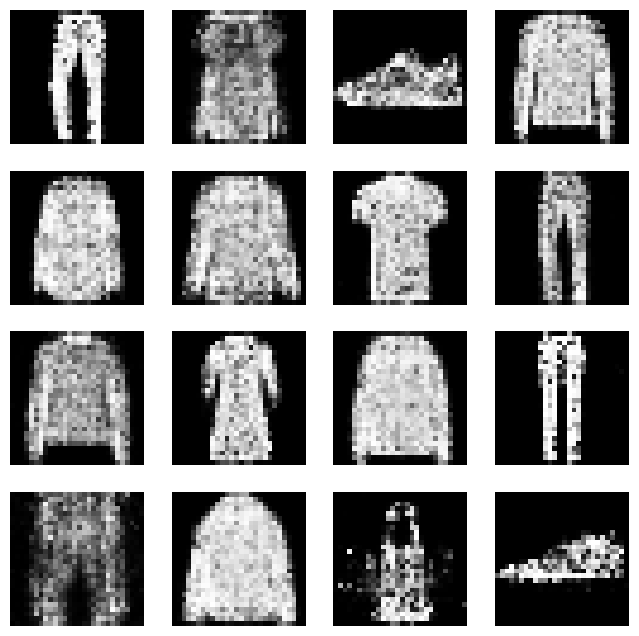

Epoch [42/50] Batch 0/469                     Loss D: 1.3136, Loss G: 0.9262
Epoch [42/50] Batch 100/469                     Loss D: 1.2797, Loss G: 0.8629
Epoch [42/50] Batch 200/469                     Loss D: 1.3248, Loss G: 0.9422
Epoch [42/50] Batch 300/469                     Loss D: 1.3173, Loss G: 0.9045
Epoch [42/50] Batch 400/469                     Loss D: 1.3440, Loss G: 0.9557


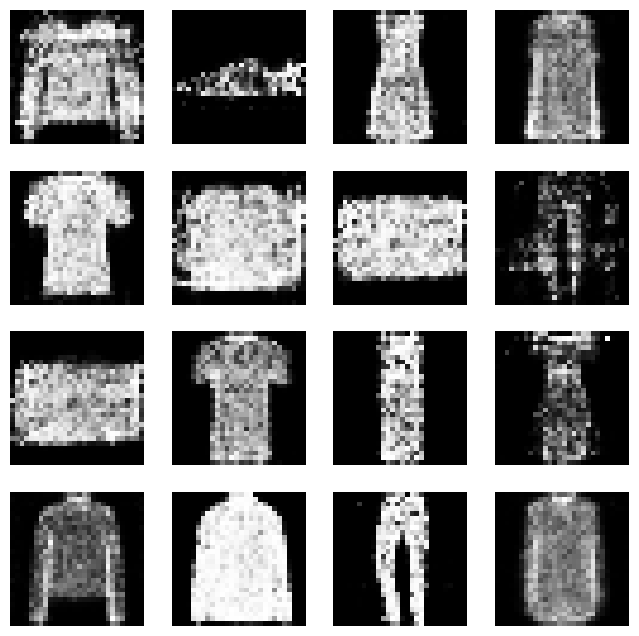

Epoch [43/50] Batch 0/469                     Loss D: 1.3132, Loss G: 0.8174
Epoch [43/50] Batch 100/469                     Loss D: 1.2281, Loss G: 0.8999
Epoch [43/50] Batch 200/469                     Loss D: 1.3452, Loss G: 0.7974
Epoch [43/50] Batch 300/469                     Loss D: 1.2684, Loss G: 0.8717
Epoch [43/50] Batch 400/469                     Loss D: 1.3148, Loss G: 0.8643


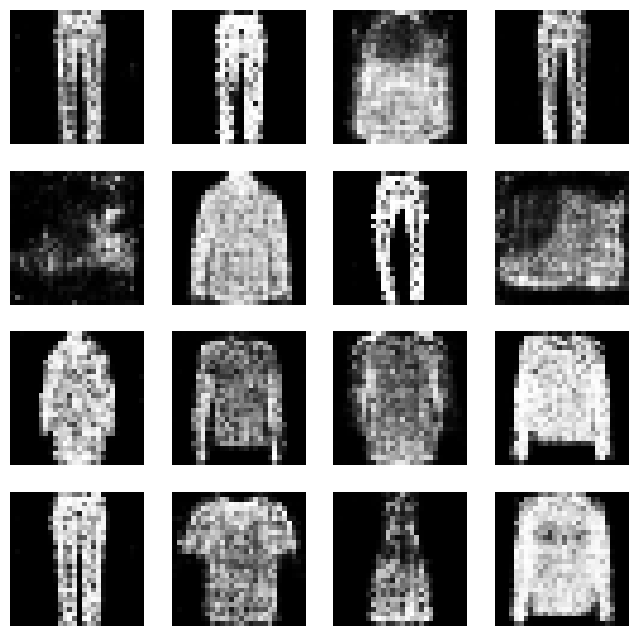

Epoch [44/50] Batch 0/469                     Loss D: 1.2864, Loss G: 0.9385
Epoch [44/50] Batch 100/469                     Loss D: 1.2363, Loss G: 0.9005
Epoch [44/50] Batch 200/469                     Loss D: 1.2891, Loss G: 0.8923
Epoch [44/50] Batch 300/469                     Loss D: 1.3007, Loss G: 0.8989
Epoch [44/50] Batch 400/469                     Loss D: 1.2271, Loss G: 0.8728


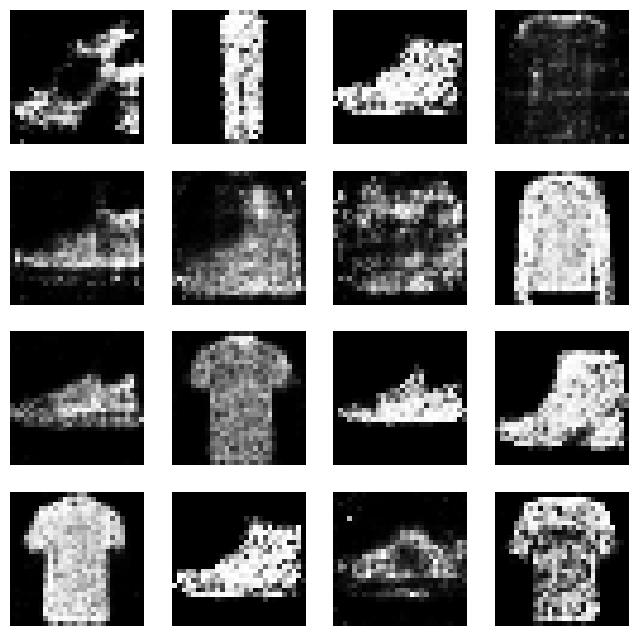

Epoch [45/50] Batch 0/469                     Loss D: 1.2614, Loss G: 0.9141
Epoch [45/50] Batch 100/469                     Loss D: 1.3026, Loss G: 0.9753
Epoch [45/50] Batch 200/469                     Loss D: 1.3597, Loss G: 0.9398
Epoch [45/50] Batch 300/469                     Loss D: 1.3901, Loss G: 0.7946
Epoch [45/50] Batch 400/469                     Loss D: 1.2899, Loss G: 0.8558


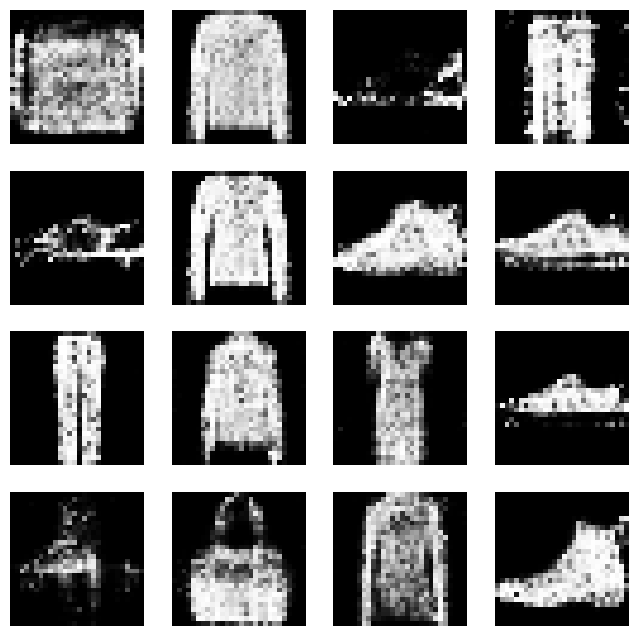

Epoch [46/50] Batch 0/469                     Loss D: 1.2439, Loss G: 0.9228
Epoch [46/50] Batch 100/469                     Loss D: 1.3117, Loss G: 0.8058
Epoch [46/50] Batch 200/469                     Loss D: 1.3137, Loss G: 0.8369
Epoch [46/50] Batch 300/469                     Loss D: 1.3522, Loss G: 0.8871
Epoch [46/50] Batch 400/469                     Loss D: 1.2657, Loss G: 1.0045


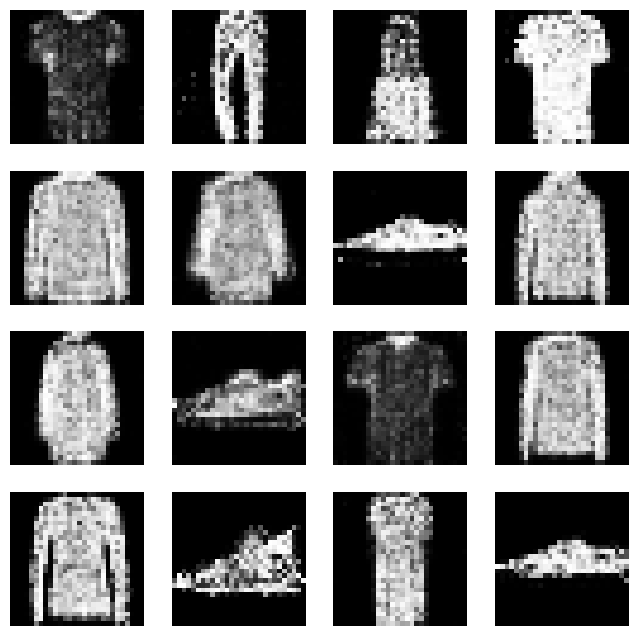

Epoch [47/50] Batch 0/469                     Loss D: 1.2952, Loss G: 0.8142
Epoch [47/50] Batch 100/469                     Loss D: 1.2578, Loss G: 0.8525
Epoch [47/50] Batch 200/469                     Loss D: 1.2593, Loss G: 0.9287
Epoch [47/50] Batch 300/469                     Loss D: 1.2840, Loss G: 0.8700
Epoch [47/50] Batch 400/469                     Loss D: 1.2668, Loss G: 0.8445


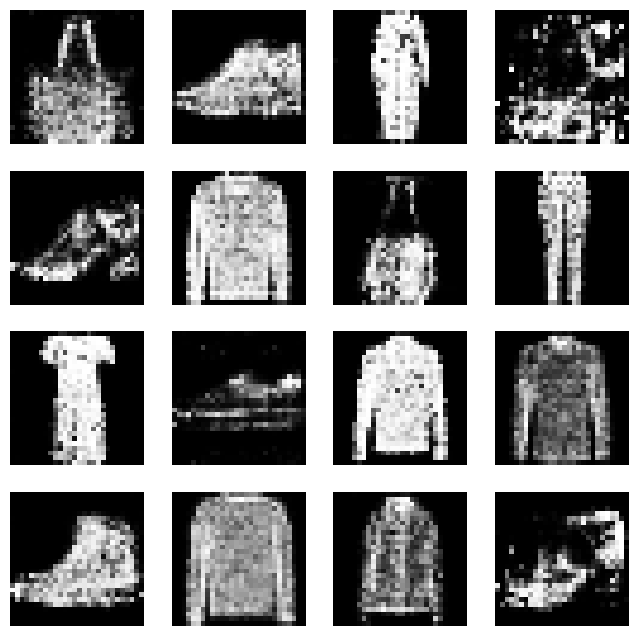

Epoch [48/50] Batch 0/469                     Loss D: 1.3025, Loss G: 0.8677
Epoch [48/50] Batch 100/469                     Loss D: 1.2890, Loss G: 0.8610
Epoch [48/50] Batch 200/469                     Loss D: 1.2673, Loss G: 0.9165
Epoch [48/50] Batch 300/469                     Loss D: 1.2385, Loss G: 0.9810
Epoch [48/50] Batch 400/469                     Loss D: 1.2582, Loss G: 0.7947


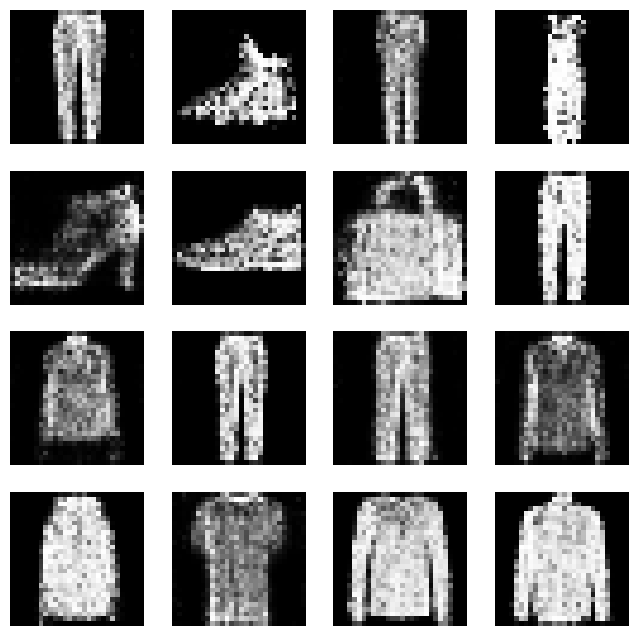

Epoch [49/50] Batch 0/469                     Loss D: 1.3239, Loss G: 0.8179
Epoch [49/50] Batch 100/469                     Loss D: 1.3172, Loss G: 0.9179
Epoch [49/50] Batch 200/469                     Loss D: 1.2445, Loss G: 0.8510
Epoch [49/50] Batch 300/469                     Loss D: 1.3049, Loss G: 0.9169
Epoch [49/50] Batch 400/469                     Loss D: 1.2369, Loss G: 0.8711


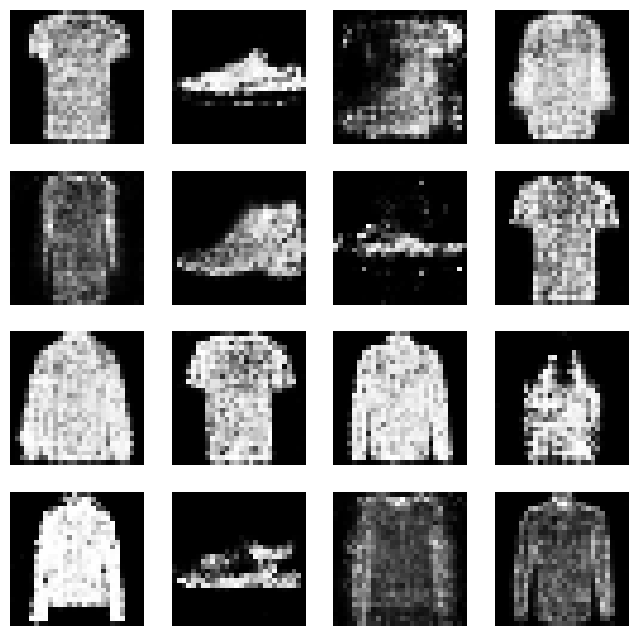

Epoch [50/50] Batch 0/469                     Loss D: 1.3358, Loss G: 0.8298
Epoch [50/50] Batch 100/469                     Loss D: 1.2182, Loss G: 0.9003
Epoch [50/50] Batch 200/469                     Loss D: 1.3168, Loss G: 0.9855
Epoch [50/50] Batch 300/469                     Loss D: 1.2206, Loss G: 0.8164
Epoch [50/50] Batch 400/469                     Loss D: 1.3072, Loss G: 0.9486


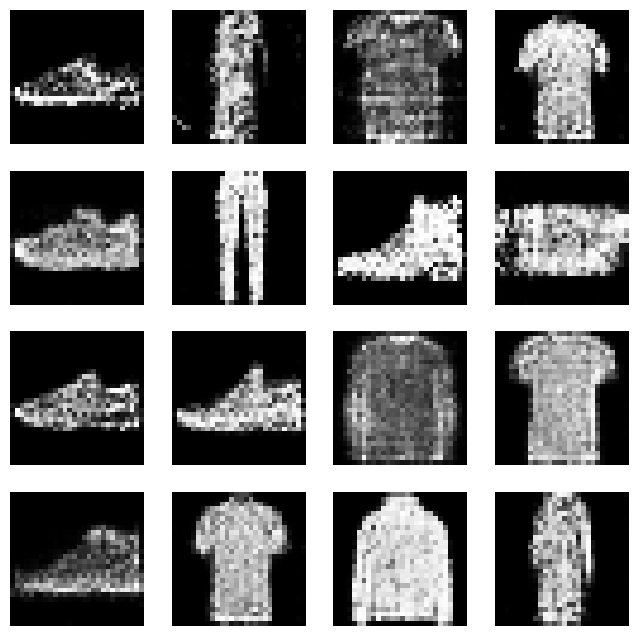

In [22]:
print("Training GAN...")
num_images = 16
noise = torch.randn(num_images, LATENT_DIM, device=DEVICE)
for epoch in range(NUM_EPOCHS):
    for i,(imgs,_) in enumerate(dataloader):
        
        discriminator.zero_grad()

        
        real_imgs = imgs.view(-1, IMAGE_SIZE).to(DEVICE)
        batch_size = real_imgs.size(0)
        labels_real = torch.full((batch_size, 1), real_label, device=DEVICE)

        output_real = discriminator(real_imgs)
        loss_real = criterion(output_real, labels_real)

        
        noise = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
        fake_imgs = generator(noise)
        labels_fake = torch.full((batch_size, 1), fake_label, device=DEVICE)

        output_fake = discriminator(fake_imgs.detach())
        loss_fake = criterion(output_fake, labels_fake)

        
        loss_D = loss_real + loss_fake
        loss_D.backward()
        optimizer_D.step()

        
        generator.zero_grad()

        
        labels_gen = torch.full((batch_size, 1), real_label, device=DEVICE)

        output_gen = discriminator(fake_imgs)
        loss_G = criterion(output_gen, labels_gen)
        loss_G.backward()
        optimizer_G.step()
        if i % 100 == 0:
            print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] Batch {i}/{len(dataloader)} \
                    Loss D: {loss_D.item():.4f}, Loss G: {loss_G.item():.4f}")
    generate_and_plot(generator, noise)